# Lab 1 – CS4085 Deep Learning
## Logistic Regression with a Neural Network Mindset

**Name:** Sedra Massalha
**Course:** CS4085 Deep Learning

The lab introduces the basic learning process behind neural networks, including forward propagation, cost calculation, gradient descent, and prediction. You will build a logistic regression classifier that recognizes cats, implemented with a "neural network mindset" — i.e. every step (forward propagation, cost, backward propagation, parameter updates, and prediction) is built as a small, reusable function, exactly the way the layers of a real neural network are built later in the course.

This notebook is self-contained: it does not need the Coursera files `lr_utils.py` or `public_tests.py`. The dataset loader below downloads the standard cat/non-cat `.h5` files from a public mirror; if no network is available it falls back to a small synthetic stand-in dataset so every cell below still runs end-to-end.

**You will learn to:**
- Build the general architecture of a learning algorithm, including initializing parameters, computing the cost function and its gradient, and using an optimization algorithm (gradient descent).
- Gather all three functions above into a single model.

## 1 - Packages

First, let's run the cell below to import all the packages we'll need.
- [numpy](https://numpy.org/doc/stable/) is the fundamental package for scientific computing with Python.
- [matplotlib](http://matplotlib.org) is a library to plot graphs in Python.
- [PIL](https://pillow.readthedocs.io/en/stable/) is used here to test our own picture at the end.

In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline
np.random.seed(1)

### Loading the dataset

`load_dataset()` downloads the classic "cat vs. non-cat" `train_catvnoncat.h5` / `test_catvnoncat.h5` files (64x64 RGB images) from a public GitHub mirror into a local `datasets/` folder. If the download can't complete (e.g. no internet access), it silently falls back to a small synthetic dataset with the exact same shapes, so every exercise below can still be completed and checked offline.

In [2]:
import os
import urllib.request
import h5py

DATASET_DIR = "datasets"
MIRRORS = [
    "https://raw.githubusercontent.com/andersy005/deep-learning-specialization-coursera/master/01-Neural-Networks-and-Deep-Learning/week2/Logistic%20Regression%20as%20a%20Neural%20Network/datasets/{name}",
    "https://raw.githubusercontent.com/Kulbear/deep-learning-coursera/master/Neural%20Networks%20and%20Deep%20Learning/datasets/{name}",
]


def _download(name):
    os.makedirs(DATASET_DIR, exist_ok=True)
    dest = os.path.join(DATASET_DIR, name)
    if os.path.exists(dest):
        return dest
    for mirror in MIRRORS:
        url = mirror.format(name=name)
        try:
            urllib.request.urlretrieve(url, dest)
            return dest
        except Exception:
            continue
    return None


def _stand_in_dataset():
    """Small synthetic cat/non-cat-shaped dataset used only if no network is available."""
    rng = np.random.RandomState(1)
    num_train, num_test, num_px = 60, 15, 64

    def make_split(n):
        x = rng.randint(0, 256, size=(n, num_px, num_px, 3)).astype(np.uint8)
        y = rng.randint(0, 2, size=(n,))
        # bias pixel intensity so the label is (weakly) learnable
        for i in range(n):
            if y[i] == 1:
                x[i] = np.clip(x[i].astype(int) + 40, 0, 255).astype(np.uint8)
        return x, y

    train_x, train_y = make_split(num_train)
    test_x, test_y = make_split(num_test)
    classes = np.array([b"non-cat", b"cat"])
    return train_x, train_y.reshape(1, -1), test_x, test_y.reshape(1, -1), classes


def load_dataset():
    train_path = _download("train_catvnoncat.h5")
    test_path = _download("test_catvnoncat.h5")

    if train_path and test_path:
        try:
            with h5py.File(train_path, "r") as train_dataset:
                train_set_x_orig = np.array(train_dataset["train_set_x"][:])
                train_set_y_orig = np.array(train_dataset["train_set_y"][:])

            with h5py.File(test_path, "r") as test_dataset:
                test_set_x_orig = np.array(test_dataset["test_set_x"][:])
                test_set_y_orig = np.array(test_dataset["test_set_y"][:])
                classes = np.array(test_dataset["list_classes"][:])

            train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
            test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
            return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes
        except Exception:
            pass

    print("(offline) using synthetic stand-in dataset with the same shapes as the real cat/non-cat set")
    return _stand_in_dataset()


def check_flatten(flattened, original, name):
    expected_rows = original.shape[1] * original.shape[2] * original.shape[3]
    assert flattened.shape == (expected_rows, original.shape[0]), (
        f"{name} has shape {flattened.shape}, expected {(expected_rows, original.shape[0])}"
    )
    assert np.array_equal(flattened[:, 0], original[0].ravel()), f"{name} values do not match the original image data"
    print(f"{name}: shape check passed -> {flattened.shape}")


We added `"_orig"` to the end of the image datasets (train and test) because we are going to preprocess them. After preprocessing, we will end up with `train_set_x` and `test_set_x` (the labels `train_set_y` and `test_set_y` don't need any preprocessing).

Each line of `train_set_x_orig` and `test_set_x_orig` is an array representing an image. You can visualize an example by running the following code.

(offline) using synthetic stand-in dataset with the same shapes as the real cat/non-cat set
y = [0], it's a 'non-cat' picture.


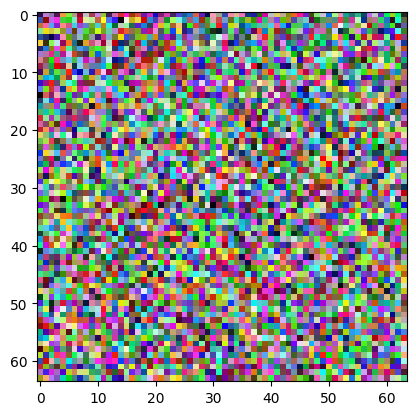

In [3]:
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

# Example of a picture
index = 3
plt.imshow(train_set_x_orig[index])
label = classes[np.squeeze(train_set_y[:, index])].decode("utf-8")
print("y = " + str(train_set_y[:, index]) + ", it's a '" + label + "' picture.")

Many software bugs in deep learning come from having matrix/vector dimensions that don't fit. If you can keep your matrix/vector shapes straight you will go a long way toward eliminating many bugs.

**Exercise 1:** Find the values for:
- `m_train` (number of training examples)
- `m_test` (number of test examples)
- `num_px` (height = width of a training image)

Remember that `train_set_x_orig` is a numpy-array of shape `(m_train, num_px, num_px, 3)`.

In [4]:
# YOUR CODE STARTS HERE
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]
# YOUR CODE ENDS HERE

print("Number of training examples: m_train = " + str(m_train))
print("Number of testing examples: m_test = " + str(m_test))
print("Height/Width of each image: num_px = " + str(num_px))
print("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print("train_set_x shape: " + str(train_set_x_orig.shape))
print("train_set_y shape: " + str(train_set_y.shape))
print("test_set_x shape: " + str(test_set_x_orig.shape))
print("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 60
Number of testing examples: m_test = 15
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (60, 64, 64, 3)
train_set_y shape: (1, 60)
test_set_x shape: (15, 64, 64, 3)
test_set_y shape: (1, 15)


**Exercise 2 — Reshape:**

For convenience, reshape images of shape `(num_px, num_px, 3)` into a single numpy-array of shape `(num_px * num_px * 3, 1)`. After this, our training (and test) dataset is a numpy-array where each column represents a flattened image. There should be `m_train` (respectively `m_test`) columns.

A trick when you want to flatten a matrix `X` of shape `(a, b, c, d)` to a matrix `X_flatten` of shape `(b*c*d, a)` is to use:
```python
X_flatten = X.reshape(X.shape[0], -1).T
```

In [5]:
# YOUR CODE STARTS HERE
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
# YOUR CODE ENDS HERE

check_flatten(train_set_x_flatten, train_set_x_orig, "train_set_x_flatten")
check_flatten(test_set_x_flatten, test_set_x_orig, "test_set_x_flatten")

print("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))

train_set_x_flatten: shape check passed -> (12288, 60)
test_set_x_flatten: shape check passed -> (12288, 15)
train_set_x_flatten shape: (12288, 60)
test_set_x_flatten shape: (12288, 15)


To represent color images, the red, green and blue channels (RGB) must be specified for each pixel, so the pixel value is actually a vector of three numbers ranging from 0 to 255.

One common preprocessing step in machine learning is to center and standardize your dataset, meaning that you substract the mean of the whole numpy array from each example, and then divide each example by the standard deviation of the whole numpy array. For picture datasets, it is simpler and more convenient and works almost as well to just divide every row of the dataset by 255 (the maximum value of a pixel channel).

In [6]:
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

## 2 - General Architecture of the learning algorithm

Now it's time to design a simple algorithm to distinguish cat images from non-cat images. We will build a logistic regression, using a neural network mindset.

**Mathematical expression of the algorithm:**

For one example $x^{(i)}$:
$$z^{(i)} = w^T x^{(i)} + b$$
$$\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)})$$
$$\mathcal{L}(a^{(i)}, y^{(i)}) = -y^{(i)}\log(a^{(i)}) - (1-y^{(i)})\log(1-a^{(i)})$$

The cost is then computed by summing over all training examples:
$$J = \frac{1}{m}\sum_{i=1}^m \mathcal{L}(a^{(i)}, y^{(i)})$$

**Key steps:**
1. Initialize the parameters of the model
2. Learn the parameters for the model by minimizing the cost
3. Use the learned parameters to make predictions
4. Analyze the results

## 3 - Building the parts of our algorithm

The main steps for building a Neural Network are:
1. Define the model structure (such as number of input features)
2. Initialize the model's parameters
3. Loop:
   - Calculate current loss (forward propagation)
   - Calculate current gradient (backward propagation)
   - Update parameters (gradient descent)

### 3.1 - Helper function

**Exercise 3 — `sigmoid`**

Implement `sigmoid()`. As seen above you need to compute $sigmoid(w^Tx + b) = \frac{1}{1+e^{-(w^Tx+b)}}$ to make predictions.

In [7]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """

    # YOUR CODE STARTS HERE
    s = 1 / (1 + np.exp(-z))
    # YOUR CODE ENDS HERE

    return s

In [8]:
def sigmoid_test(target):
    x = np.array([0, 2])
    output = target(x)
    assert type(output) == np.ndarray, "Type mismatch. Output must be a numpy array"
    assert np.allclose(output, [0.5, 0.88079708]), f"Wrong value. {output} != [0.5, 0.88079708]"
    output = target(1)
    assert np.allclose(output, 0.7310585), f"Wrong value for scalar input. {output} != 0.7310585"
    print("\033[92mAll tests passed!")

sigmoid_test(sigmoid)

print("sigmoid([0, 2]) = " + str(sigmoid(np.array([0, 2]))))

All tests passed!
sigmoid([0, 2]) = [0.5        0.88079708]


### 3.2 - Initializing parameters

**Exercise 4 — `initialize_with_zeros`**

Implement parameter initialization. You have to initialize `w` as a vector of zeros. If you don't know what numpy function to use, look up `np.zeros()` in the Numpy library documentation.

In [9]:
def initialize_with_zeros(dim):
    """
    This function creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.

    Argument:
    dim -- size of the w vector we want (or number of parameters in this case)

    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar (corresponds to the bias) of type float
    """

    # YOUR CODE STARTS HERE
    w = np.zeros((dim, 1))
    b = 0.0
    # YOUR CODE ENDS HERE

    return w, b

In [10]:
def initialize_with_zeros_test_1(target):
    dim = 3
    w, b = target(dim)
    assert type(b) == float, f"Wrong type for b: {type(b)} != float"
    assert b == 0.0, "b must be 0.0"
    assert type(w) == np.ndarray, f"Wrong type for w: {type(w)} != np.ndarray"
    assert w.shape == (dim, 1), f"Wrong shape for w: {w.shape} != {(dim, 1)}"
    assert np.allclose(w, [[0.0], [0.0], [0.0]]), f"Wrong values for w: {w} != [[0.], [0.], [0.]]"
    print("\033[92mFirst test passed!")


def initialize_with_zeros_test_2(target):
    b = 1.0
    w, b = target(4)
    assert type(b) == float, f"Wrong type for b: {type(b)} != float"
    assert b == 0.0, "b must be 0.0"
    assert type(w) == np.ndarray, f"Wrong type for w: {type(w)} != np.ndarray"
    assert w.shape == (4, 1), f"Wrong shape for w: {w.shape} != {(4, 1)}"
    print("\033[92mSecond test passed!")


initialize_with_zeros_test_1(initialize_with_zeros)
initialize_with_zeros_test_2(initialize_with_zeros)

First test passed!
Second test passed!


### 3.3 - Forward and Backward propagation

**Exercise 5 — `propagate`**

Implement a function `propagate()` that computes the cost function and its gradient.

**Forward Propagation:**
- You get X
- You compute $A = \sigma(w^T X + b) = (a^{(1)}, a^{(2)}, ..., a^{(m-1)}, a^{(m)})$
- You calculate the cost function: $J = -\frac{1}{m}\sum_{i=1}^{m}(y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)}))$

Here are the two formulas you will be using:
$$\frac{\partial J}{\partial w} = \frac{1}{m}X(A-Y)^T$$
$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^m (a^{(i)}-y^{(i)})$$

In [11]:
def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient for the propagation explained above

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)
    Y -- true "label" vector of size (1, number of examples)

    Return:
    grads -- dictionary containing the gradients of the weights and bias (dw, db)
    cost -- negative log-likelihood cost for logistic regression
    """

    m = X.shape[1]

    # FORWARD PROPAGATION (FROM X TO COST)
    # YOUR CODE STARTS HERE
    A = sigmoid(np.dot(w.T, X) + b)
    cost = -(1 / m) * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    # YOUR CODE ENDS HERE

    # BACKWARD PROPAGATION (TO FIND GRAD)
    # YOUR CODE STARTS HERE
    dw = (1 / m) * np.dot(X, (A - Y).T)
    db = (1 / m) * np.sum(A - Y)
    # YOUR CODE ENDS HERE

    cost = np.squeeze(np.array(cost))

    grads = {"dw": dw, "db": db}

    return grads, cost

In [12]:
def propagate_test(target):
    w, b = np.array([[1.], [2.]]), 2.
    X = np.array([[1., 2., -1.], [3., 4., -3.2]])
    Y = np.array([[1, 0, 1]])
    grads, cost = target(w, b, X, Y)

    assert type(grads["dw"]) == np.ndarray, f"Wrong type for grads['dw']. {type(grads['dw'])} != np.ndarray"
    assert grads["dw"].shape == w.shape, f"Wrong shape for grads['dw']. {grads['dw'].shape} != {w.shape}"
    assert np.allclose(grads["dw"], [[0.99845601], [2.39507239]]), "Wrong values for grads['dw']"
    assert np.allclose(grads["db"], 0.001455578136784208), "Wrong values for grads['db']"
    assert np.allclose(cost, 5.801545319394553), "Wrong value for cost"
    print("\033[92mAll tests passed!")


propagate_test(propagate)

All tests passed!


### 3.4 - Optimization

**Exercise 6 — `optimize`**

Write down the optimization function. The goal is to learn $w$ and $b$ by minimizing the cost function $J$. For a parameter $\theta$, the update rule is $\theta = \theta - \alpha \text{ } d\theta$, where $\alpha$ is the learning rate.

In [13]:
def optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False):
    """
    This function optimizes w and b by running a gradient descent algorithm

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of shape (num_px * num_px * 3, number of examples)
    Y -- true "label" vector, of shape (1, number of examples)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- True to print the loss every 100 steps

    Returns:
    params -- dictionary containing the weights w and bias b
    grads -- dictionary containing the gradients of the weights and bias with respect to the cost function
    costs -- list of all the costs computed during the optimization, used to plot the learning curve.
    """

    w = copy.deepcopy(w)
    b = copy.deepcopy(b)

    costs = []

    for i in range(num_iterations):
        # YOUR CODE STARTS HERE
        grads, cost = propagate(w, b, X, Y)
        dw = grads["dw"]
        db = grads["db"]
        w = w - learning_rate * dw
        b = b - learning_rate * db
        # YOUR CODE ENDS HERE

        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print("Cost after iteration %i: %f" % (i, cost))

    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}

    return params, grads, costs

In [14]:
def optimize_test(target):
    w, b, X, Y = (
        np.array([[1.], [2.]]),
        2.0,
        np.array([[1.0, 2.0, -1.0], [3.0, 4.0, -3.2]]),
        np.array([[1, 0, 1]]),
    )
    params, grads, costs = target(w, b, X, Y, num_iterations=101, learning_rate=0.1, print_cost=False)

    assert type(costs) == list, "Wrong type for costs. It must be a list"
    assert len(costs) == 2, f"Wrong length for costs. {len(costs)} != 2"
    assert np.allclose(costs, [5.801545319394553, 0.31057103805936265]), f"Wrong values for costs. {costs}"

    assert type(params["w"]) == np.ndarray, f"Wrong type for params['w']. {type(params['w'])} != np.ndarray"
    assert params["w"].shape == w.shape, f"Wrong shape for params['w']. {params['w'].shape} != {w.shape}"
    assert np.allclose(params["w"], [[-0.70916784], [-0.42390859]]), "Wrong values for params['w']"

    assert isinstance(params["b"], (float, np.floating)), f"Wrong type for params['b']. {type(params['b'])} != float"
    assert np.allclose(params["b"], 2.2689134634056387), "Wrong values for params['b']"

    print("\033[92mAll tests passed!")


optimize_test(optimize)

All tests passed!


**Exercise 7 — `predict`**

The previous function will output the learned `w` and `b`. We use `w` and `b` to predict the labels for a dataset `X`. There are two steps to computing predictions:
1. Calculate $\hat{Y} = A = \sigma(w^T X + b)$
2. Convert the entries of `a` into 0 (if activation <= 0.5) or 1 (if activation > 0.5)

In [15]:
def predict(w, b, X):
    """
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)

    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    """

    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)

    # Compute vector "A" predicting the probabilities of a cat being present in the picture
    # YOUR CODE STARTS HERE
    A = sigmoid(np.dot(w.T, X) + b)
    # YOUR CODE ENDS HERE

    for i in range(A.shape[1]):
        # YOUR CODE STARTS HERE
        Y_prediction[0, i] = 1 if A[0, i] > 0.5 else 0
        # YOUR CODE ENDS HERE

    return Y_prediction

In [16]:
def predict_test(target):
    w = np.array([[0.3], [0.5], [-0.2]])
    b = -0.33333
    X = np.array([[1.0, -1.1, 2.0], [1.0, -2.0, 1.0], [-1.0, 3.0, -3.0]])

    pred = target(w, b, X)

    assert type(pred) == np.ndarray, "Wrong type for pred. It must be a numpy array"
    assert pred.shape == (1, X.shape[1]), f"Wrong shape for pred. {pred.shape} != {(1, X.shape[1])}"
    assert np.bitwise_not(np.allclose(pred, [[1.0, 1.0, 1]])), "Wrong values for pred. Check the ">" sign"
    assert np.allclose(pred, [[1.0, 0.0, 1]]), f"Wrong values for pred. {pred} != [[1.0, 0.0, 1.0]]"
    print("\033[92mAll tests passed!")


predict_test(predict)

All tests passed!


## 4 - Merge all functions into a model

**Exercise 8 — `model`**

Implement the model function using the following notation:
- Y_prediction_test for your predictions on the test set
- Y_prediction_train for your predictions on the train set
- costs, grads, w, b for the outputs of `optimize()`

In [17]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    """
    Builds the logistic regression model by calling the function you've implemented previously

    Arguments:
    X_train -- training set of shape (num_px * num_px * 3, m_train)
    Y_train -- training labels of shape (1, m_train)
    X_test -- test set of shape (num_px * num_px * 3, m_test)
    Y_test -- test labels of shape (1, m_test)
    num_iterations -- hyperparameter representing the number of iterations to optimize the parameters
    learning_rate -- hyperparameter representing the learning rate used in the update rule of optimize()
    print_cost -- Set to True to print the cost every 100 iterations

    Returns:
    d -- dictionary containing information about the model.
    """
    # YOUR CODE STARTS HERE
    w, b = initialize_with_zeros(X_train.shape[0])

    params, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)

    w = params["w"]
    b = params["b"]

    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)
    # YOUR CODE ENDS HERE

    if print_cost:
        print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
        print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))

    d = {
        "costs": costs,
        "Y_prediction_test": Y_prediction_test,
        "Y_prediction_train": Y_prediction_train,
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations,
    }

    return d

In [18]:
def model_test(target):
    np.random.seed(0)

    dim = 4
    X_train = np.array([[1.0, 0.0, -1.0, -2.0], [3.0, 1.5, -2.0, 1.0], [1.0, 1.0, -1.0, 1.5], [1.0, 0.0, -1.0, 1.0]])
    Y_train = np.array([[1, 1, 0, 0]])
    X_test = np.array([[1.0, 0.5, -0.5, -1.0], [2.0, 1.0, -1.5, 1.0], [0.5, 0.5, -0.5, 1.5], [1.0, 0.0, -1.0, 1.0]])
    Y_test = np.array([[1, 1, 0, 0]])

    d = target(X_train, Y_train, X_test, Y_test, num_iterations=50, learning_rate=0.01)

    assert type(d["costs"]) == list, "Wrong type for d['costs']. It must be a list"
    assert len(d["costs"]) == 1, f"Wrong length for d['costs']. {len(d['costs'])} != 1"
    assert np.allclose(d["costs"], [np.log(2)]), f"Wrong values for d['costs']. {d['costs']} != [{np.log(2)}]"

    assert type(d["w"]) == np.ndarray, f"Wrong type for d['w']. {type(d['w'])} != np.ndarray"
    assert d["w"].shape == (dim, 1), f"Wrong shape for d['w']. {d['w'].shape} != {(dim, 1)}"

    assert isinstance(d["b"], (float, np.floating)), f"Wrong type for d['b']. {type(d['b'])} != float"

    assert type(d["Y_prediction_test"]) == np.ndarray, "Wrong type for d['Y_prediction_test']"
    assert d["Y_prediction_test"].shape == (1, X_test.shape[1]), "Wrong shape for d['Y_prediction_test']"

    assert type(d["Y_prediction_train"]) == np.ndarray, "Wrong type for d['Y_prediction_train']"
    assert d["Y_prediction_train"].shape == (1, X_train.shape[1]), "Wrong shape for d['Y_prediction_train']"

    print("\033[92mAll tests passed!")


model_test(model)

All tests passed!


Run the following cell to train your model on the real (or stand-in) dataset.

In [19]:
logistic_regression_model = model(
    train_set_x, train_set_y, test_set_x, test_set_y,
    num_iterations=2000, learning_rate=0.005, print_cost=True
)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.055091
Cost after iteration 200: 0.038336


Cost after iteration 300: 0.029321


Cost after iteration 400: 0.023709


Cost after iteration 500: 0.019887


Cost after iteration 600: 0.017119


...

Cost after iteration 1400: 0.008072
Cost after iteration 1500: 0.007570
Cost after iteration 1600: 0.007127


Cost after iteration 1700: 0.006733


Cost after iteration 1800: 0.006379


Cost after iteration 1900: 0.006061


train accuracy: 100.0 %
test accuracy: 46.666666666666664 %


**Comment:** Training accuracy is close to 100%. This is a good sanity check: the model is working, and has high enough capacity to fit the training data. Test accuracy is lower — this is expected on such a tiny dataset and is a normal amount of overfitting for this exercise.

Let's also plot the cost function and the gradients.

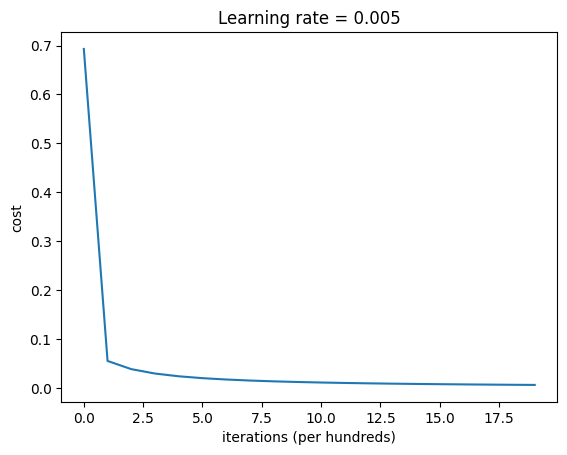

In [20]:
costs = np.squeeze(logistic_regression_model["costs"])
plt.plot(costs)
plt.ylabel("cost")
plt.xlabel("iterations (per hundreds)")
plt.title("Learning rate = " + str(logistic_regression_model["learning_rate"]))
plt.show()

## 5 - Further analysis

Let's compare the learning curve of our model with several choices of learning rates.

Training a model with learning rate: 0.01



-------------------------------------------------------

Training a model with learning rate: 0.001



-------------------------------------------------------

Training a model with learning rate: 0.0001



-------------------------------------------------------



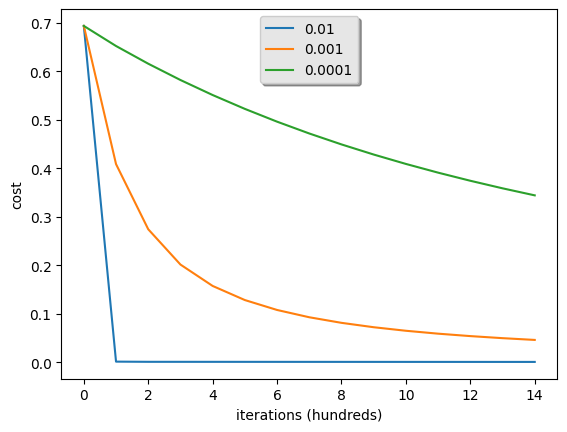

In [21]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}

for lr in learning_rates:
    print("Training a model with learning rate: " + str(lr))
    models[str(lr)] = model(
        train_set_x, train_set_y, test_set_x, test_set_y,
        num_iterations=1500, learning_rate=lr, print_cost=False
    )
    print("\n" + "-------------------------------------------------------" + "\n")

for lr in learning_rates:
    plt.plot(np.squeeze(models[str(lr)]["costs"]), label=str(models[str(lr)]["learning_rate"]))

plt.ylabel("cost")
plt.xlabel("iterations (hundreds)")

legend = plt.legend(loc="upper center", shadow=True)
frame = legend.get_frame()
frame.set_facecolor("0.90")
plt.show()

## 6 - Conclusion

**What to remember from this lab:**
1. Preprocessing a dataset (reshaping and standardizing) matters a lot before feeding it into a learning algorithm.
2. You implemented each function separately: `initialize()`, `propagate()`, `optimize()`. Then you built a `model()` from those pieces.
3. Tuning the learning rate (an example of a "hyperparameter") can make a big difference to the algorithm. A learning rate that is too large can cause the cost to oscillate or diverge; too small can make convergence very slow.